In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Set the root path as if it's being ran from the project root
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)

In [19]:
import pygad
import numpy as np
import torch
import os
from ga.components.ga import on_crossover_func, on_generation_func, calculate_dynamic_probs
from ga.components.fitness import constrained_fitness_func
from ga.components.mutation import paper_style_mutation, random_float_mutation, custom_mutation
from ga.components.crossover import pixel_cleaning_operation
from ga.components.model import load_model, evaluate_without_perturbation, evaluate_with_perturbation
from ga.utils import get_dataloader, visualize_images_batch,visualize_image, visualize_perturbation, compute_pixel_statistics, load_config

In [5]:
# Use GPU instead of CPU

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Parameters

In [6]:
config = load_config()

In [7]:
# num_generations =num_generations=config["ga"]["num_generations"]
# num_parents_mating=config["ga"]["num_parents_mating"]
# sol_per_pop=config["ga"]["sol_per_pop"]
# init_range_low=config["ga"]["init_range_low"]
# init_range_high=config["ga"]["init_range_high"]
# mutation_percent_genes=config["ga"]["mutation_percent_genes"]

# model_type = config["model"]["model_type"]
# batch_size = config["model"]["batch_size"]

# visualize = config["visualization"]["visualize"]
# visualize_every = config["visualization"]["visualize_every"]


# Model

In [8]:
model = load_model(config["model"]["model_type"], device=device)

Loading model: googlenet
Using device: mps


# Loading

In [9]:
# Load
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
image_dir = os.path.join(project_root, "nn/data/imagenet/val")
dataloader = get_dataloader(config["model"]["batch_size"], image_dir)


## Compute statistics - no need to run now

In [10]:
# Compute the pixel mean and standard deviation for each pixel across the entire dataset - for constrained fitness func

# pixel_mean, pixel_std = compute_pixel_statistics(dataloader)

# Roughly 0.04, 1.18, since we already normalize the dataset

In [11]:
# First batch
input_batch, labels = next(iter(dataloader))
input_batch, labels = input_batch.to(device), labels.to(device)

# Collect top perturbations from each generation
top_perturbations = []

# GA Config


Generation 1 completed with fitness: [-1.17719116 -1.29375458 -1.29757385 -1.24724731 -1.22630768 -1.19599152
 -1.2368042  -1.26019592 -1.24095001 -1.18149414 -1.19573059 -1.27320862
 -1.27977295 -1.21069946 -1.28620758 -1.23207855 -1.20834503 -1.14306183
 -1.25595398 -1.19134521 -1.19571991 -1.34457092 -1.28213806 -1.28234863
 -1.15469513 -1.27124634 -1.28694458 -1.23492126 -1.23193207 -1.24845123
 -1.26058502 -1.20098114 -1.20090027 -1.22129517 -1.22029724 -1.23502808
 -1.2528656  -1.21647491 -1.19375916 -1.28753204]
Best Fitness = -1.1430618286132814

Best solution snippet: [-0.19721782 -0.17174421 -0.49273978 -0.08845827  0.30844649  0.33185166
 -0.16798375 -0.29539456  0.          0.        ]
Best solution zeros count: 15197
Best perturbation magnitude: 105.79339599609375
New crossover & mutation probabilities: 0.86875, 0.575

Generation 2 completed with fitness: [-0.74742737 -0.71591797 -0.74047089 -0.77606506 -0.74116058 -0.75484772
 -0.76049042 -0.82658386 -0.80592194 -0.77583

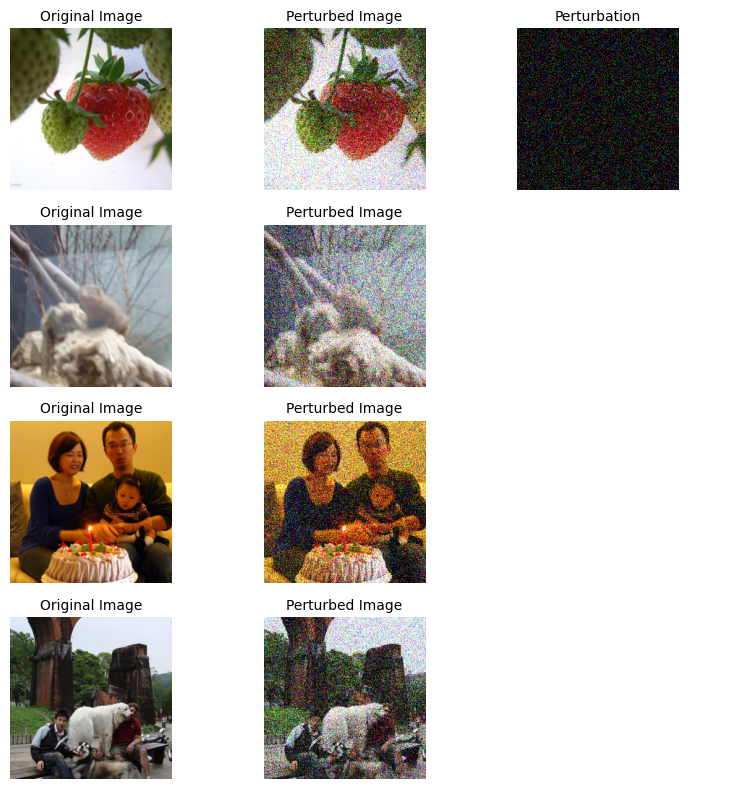

New crossover & mutation probabilities: 0.775, 0.5

Generation 5 completed with fitness: [0.3714859  0.38218842 0.35026855 0.34077759 0.34282837 0.29612579
 0.35715027 0.36286316 0.3371933  0.35138397 0.31277771 0.36561432
 0.28101807 0.35061188 0.41291962 0.31869812 0.31174622 0.35758972
 0.32620544 0.33947601 0.37338409 0.33839874 0.3066864  0.28121948
 0.30918274 0.33938141 0.28854675 0.3360733  0.38554993 0.41443329
 0.39281158 0.30982819 0.32697906 0.38794556 0.35231323 0.34941254
 0.30750275 0.32786865 0.38952942 0.30534363]
Best Fitness = 0.41443328857421874

Best solution snippet: [-0.19721782  0.12652577  0.         -0.08845827  0.30844649  0.
 -0.16798375  0.          0.          0.        ]
Best solution zeros count: 61903
Best perturbation magnitude: 85.5059585571289
New crossover & mutation probabilities: 0.74375, 0.475

Generation 6 completed with fitness: [0.60899658 0.59375    0.56332092 0.56604767 0.55146179 0.5916153
 0.56252289 0.55014191 0.640625   0.54645996 0.5807

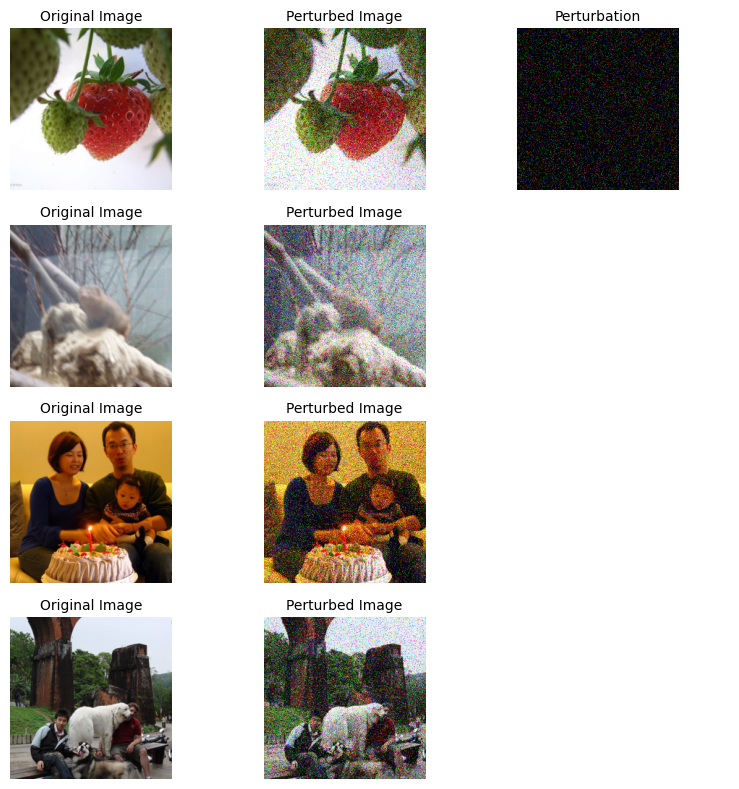

New crossover & mutation probabilities: 0.65, 0.4

Generation 9 completed with fitness: [0.578125 0.609375 0.578125 0.59375  0.625    0.578125 0.59375  0.59375
 0.59375  0.5625   0.59375  0.578125 0.609375 0.59375  0.59375  0.59375
 0.609375 0.5625   0.609375 0.546875 0.609375 0.5625   0.578125 0.578125
 0.59375  0.59375  0.5625   0.59375  0.5625   0.59375  0.5625   0.5625
 0.5625   0.5625   0.59375  0.59375  0.578125 0.59375  0.59375  0.578125]
Best Fitness = 0.625

Best solution snippet: [-0.19721782  0.          0.         -0.08845827  0.          0.
  0.          0.         -0.49323067  0.        ]
Best solution zeros count: 91760
Best perturbation magnitude: 69.645263671875
New crossover & mutation probabilities: 0.61875, 0.375

Generation 10 completed with fitness: [0.609375 0.609375 0.59375  0.59375  0.53125  0.625    0.578125 0.5625
 0.59375  0.5625   0.546875 0.5625   0.59375  0.578125 0.578125 0.578125
 0.609375 0.609375 0.578125 0.578125 0.578125 0.515625 0.609375 0.59375
 0

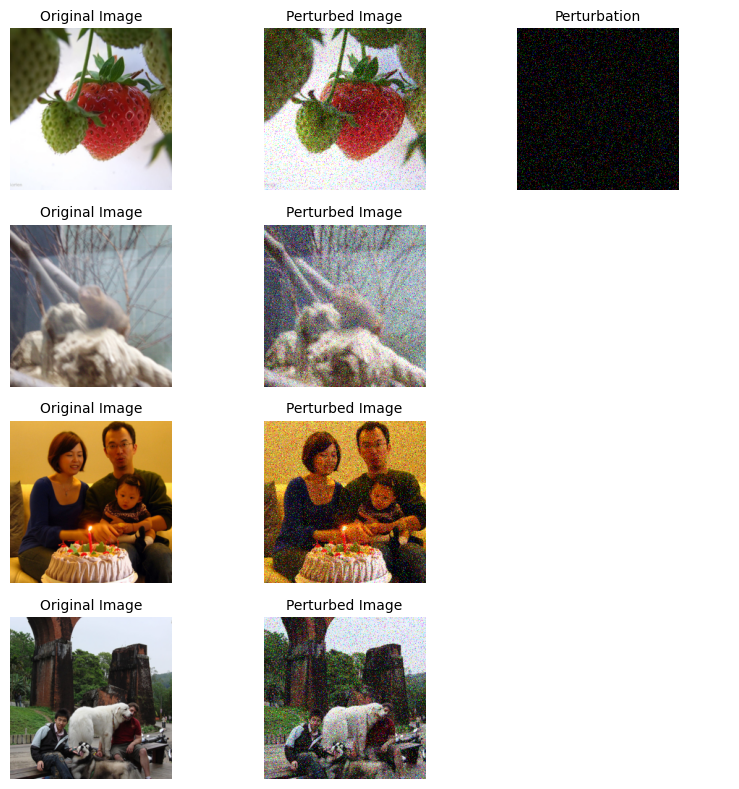

New crossover & mutation probabilities: 0.525, 0.3

Generation 13 completed with fitness: [0.578125 0.59375  0.609375 0.59375  0.59375  0.578125 0.609375 0.609375
 0.625    0.59375  0.59375  0.59375  0.59375  0.59375  0.578125 0.578125
 0.5625   0.59375  0.59375  0.59375  0.578125 0.578125 0.578125 0.578125
 0.59375  0.59375  0.59375  0.609375 0.578125 0.609375 0.609375 0.5625
 0.578125 0.59375  0.578125 0.609375 0.609375 0.609375 0.578125 0.59375 ]
Best Fitness = 0.625

Best solution snippet: [ 0.          0.          0.         -0.08845827  0.          0.
  0.          0.          0.          0.        ]
Best solution zeros count: 111730
Best perturbation magnitude: 56.59177780151367
New crossover & mutation probabilities: 0.49375, 0.275

Generation 14 completed with fitness: [0.578125 0.59375  0.59375  0.59375  0.59375  0.609375 0.609375 0.59375
 0.59375  0.609375 0.625    0.59375  0.609375 0.59375  0.5625   0.59375
 0.5625   0.59375  0.5625   0.578125 0.5625   0.59375  0.59375  0.5

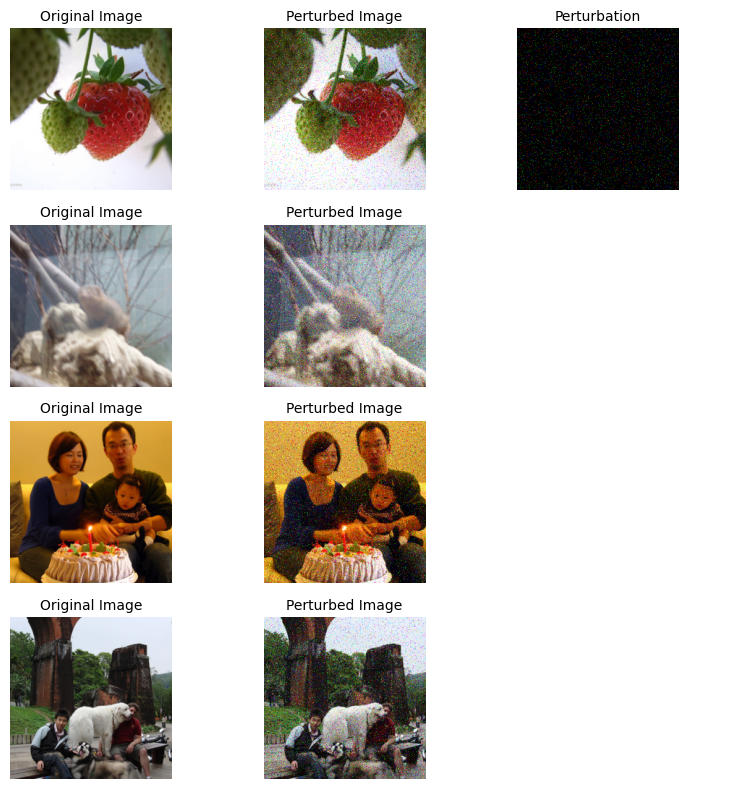

New crossover & mutation probabilities: 0.4, 0.2


In [27]:
config = load_config()

ga_instance = pygad.GA(
    num_generations=config["ga"]["num_generations"],
    num_parents_mating=config["ga"]["num_parents_mating"],
    sol_per_pop=config["ga"]["sol_per_pop"],
    num_genes=3*224*224,
    gene_type=float,
    init_range_low=config["ga"]["init_range_low"],
    init_range_high=config["ga"]["init_range_high"],
    parent_selection_type=config["ga"]["parent_selection_type"],
    keep_elitism=config["ga"]["keep_elitism"],
    keep_parents=config["ga"]["keep_parents"],
    crossover_type=config["crossover"]["crossover_type"],
    crossover_probability=config["crossover"]["crossover_probability"],
    mutation_type=lambda ga_inst, offspring: paper_style_mutation(ga_inst, offspring, config["mutation"]["p_m"], config["mutation"]["p_flip"]),
    fitness_func=lambda ga_inst, solution, solution_idx: constrained_fitness_func(
        ga_inst, solution, solution_idx, model, input_batch, labels, config["fitness"]["pixel_constraint_weight"], config["fitness"]["max_perturbation_magnitude"], config["fitness"]["epsilon_init"], config["fitness"]["epsilon_end"], config["fitness"]["penalty_factor"]
    ),
    on_generation=lambda ga_inst: on_generation_func(ga_inst, input_batch, top_perturbations, config),
    on_crossover=lambda ga_inst, offspring: on_crossover_func(ga_inst, offspring, config),
)

ga_instance.run()

In [138]:
input_batch.shape

torch.Size([64, 3, 224, 224])

In [139]:
# After the run
solution, solution_fitness, _ = ga_instance.best_solution()
print(f"Best solution fitness: {solution_fitness}") # Might be the penultimate best fitness??

Best solution fitness: -1.8121788024902346


# Calculating Universal Perturbation

torch.Size([3, 224, 224])
Universal perturbation created.


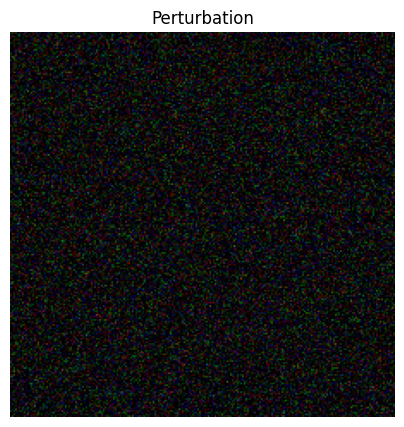

In [140]:
if len(top_perturbations) > 0:
    universal_perturbation = torch.mean(torch.stack(top_perturbations), dim=0)
    print(universal_perturbation.shape)
    print(f"Universal perturbation created.")
    visualize_perturbation(universal_perturbation)

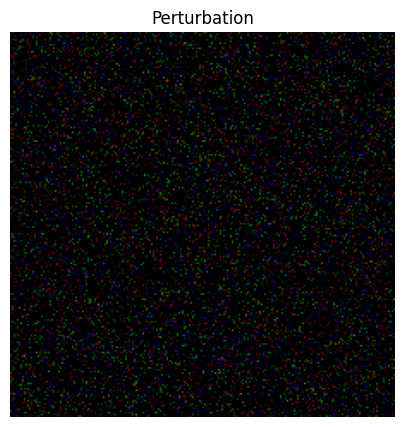

In [162]:
# Take the last one only (much smaller norm)
universal_perturbation = top_perturbations[-1]
visualize_perturbation(universal_perturbation)

# Metrics
(takes a while)

### GoogLeNet
(4 min)

In [155]:
evaluate_without_perturbation(model, dataloader, device)
# 0.6977

Using device: mps
Accuracy without perturbation: 0.69772


0.69772

In [161]:
evaluate_with_perturbation(model, dataloader, universal_perturbation, device)
# 9/24: 0.37964

# 12/24: 0.39556 (mean (higher norm)), 0.4017 (last one only)

Using device: mps
Accuracy with perturbation: 0.40172


0.40172

### ViT b 16

In [ ]:
evaluate_without_perturbation(model, dataloader, device)
# 0.811
# 13 mins

Using device: cpu


RuntimeError: Mismatched Tensor types in NNPack convolutionOutput

In [ ]:
evaluate_with_perturbation(model, dataloader, universal_perturbation, device)